In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# read the data set

In [ ]:
data=(r"C:\Users\pc\Documents\files.csv\dataset.csv")
df=pd.read_csv( data, sep=';')
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


## Exploratory data analysis for data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [ ]:
df.shape

(4424, 35)

In [ ]:
for var in df:

    print(df[var].value_counts())

1    3919
2     379
4      91
5      25
6       6
3       4
Name: Marital status, dtype: int64
1     1708
8      872
12     785
14     312
15     213
4      139
9      124
13      77
16      59
7       38
17      35
6       30
3       16
5       10
2        3
10       1
18       1
11       1
Name: Application mode, dtype: int64
1    3026
2     547
3     309
4     249
5     154
6     137
0       1
9       1
Name: Application order, dtype: int64
12    766
9     380
10    355
6     337
15    331
14    268
17    268
11    252
5     226
2     215
3     215
4     210
16    192
7     170
8     141
13     86
1      12
Name: Course, dtype: int64
1    3941
0     483
Name: Daytime/evening attendance, dtype: int64
1     3717
14     219
12     162
3      126
9       45
15      40
16      36
2       23
6       16
7       11
4        8
13       7
17       6
8        4
11       2
10       1
5        1
Name: Previous qualification, dtype: int64
1     4314
14      38
12      14
9       13
3       13
10 

In [ ]:
df.isna().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

In [ ]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# outlier

In [ ]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Text(0, 0.5, 'Nacionality')

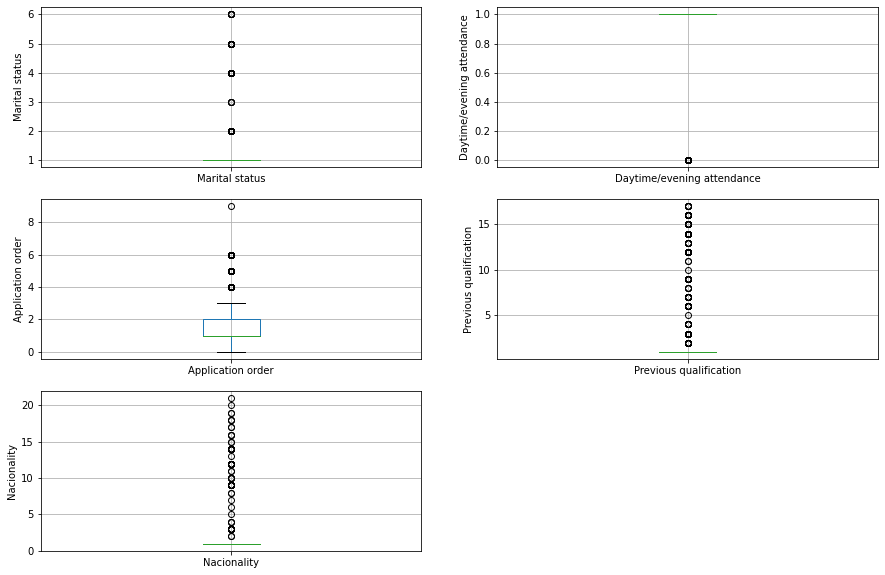

In [ ]:

plt.figure(figsize=(15,10))


plt.subplot(3, 2, 1)
fig = df.boxplot(column='Marital status')
fig.set_title('')
fig.set_ylabel('Marital status')


plt.subplot(3, 2, 2)
fig = df.boxplot(column='Daytime/evening attendance')
fig.set_title('')
fig.set_ylabel('Daytime/evening attendance')


plt.subplot(3, 2, 3)
fig = df.boxplot(column='Application order')
fig.set_title('')
fig.set_ylabel('Application order')


plt.subplot(3, 2, 4)
fig = df.boxplot(column='Previous qualification')
fig.set_title('')
fig.set_ylabel('Previous qualification')

plt.subplot(3, 2, 5)
fig = df.boxplot(column='Nacionality')
fig.set_title('')
fig.set_ylabel('Nacionality')



<AxesSubplot:>

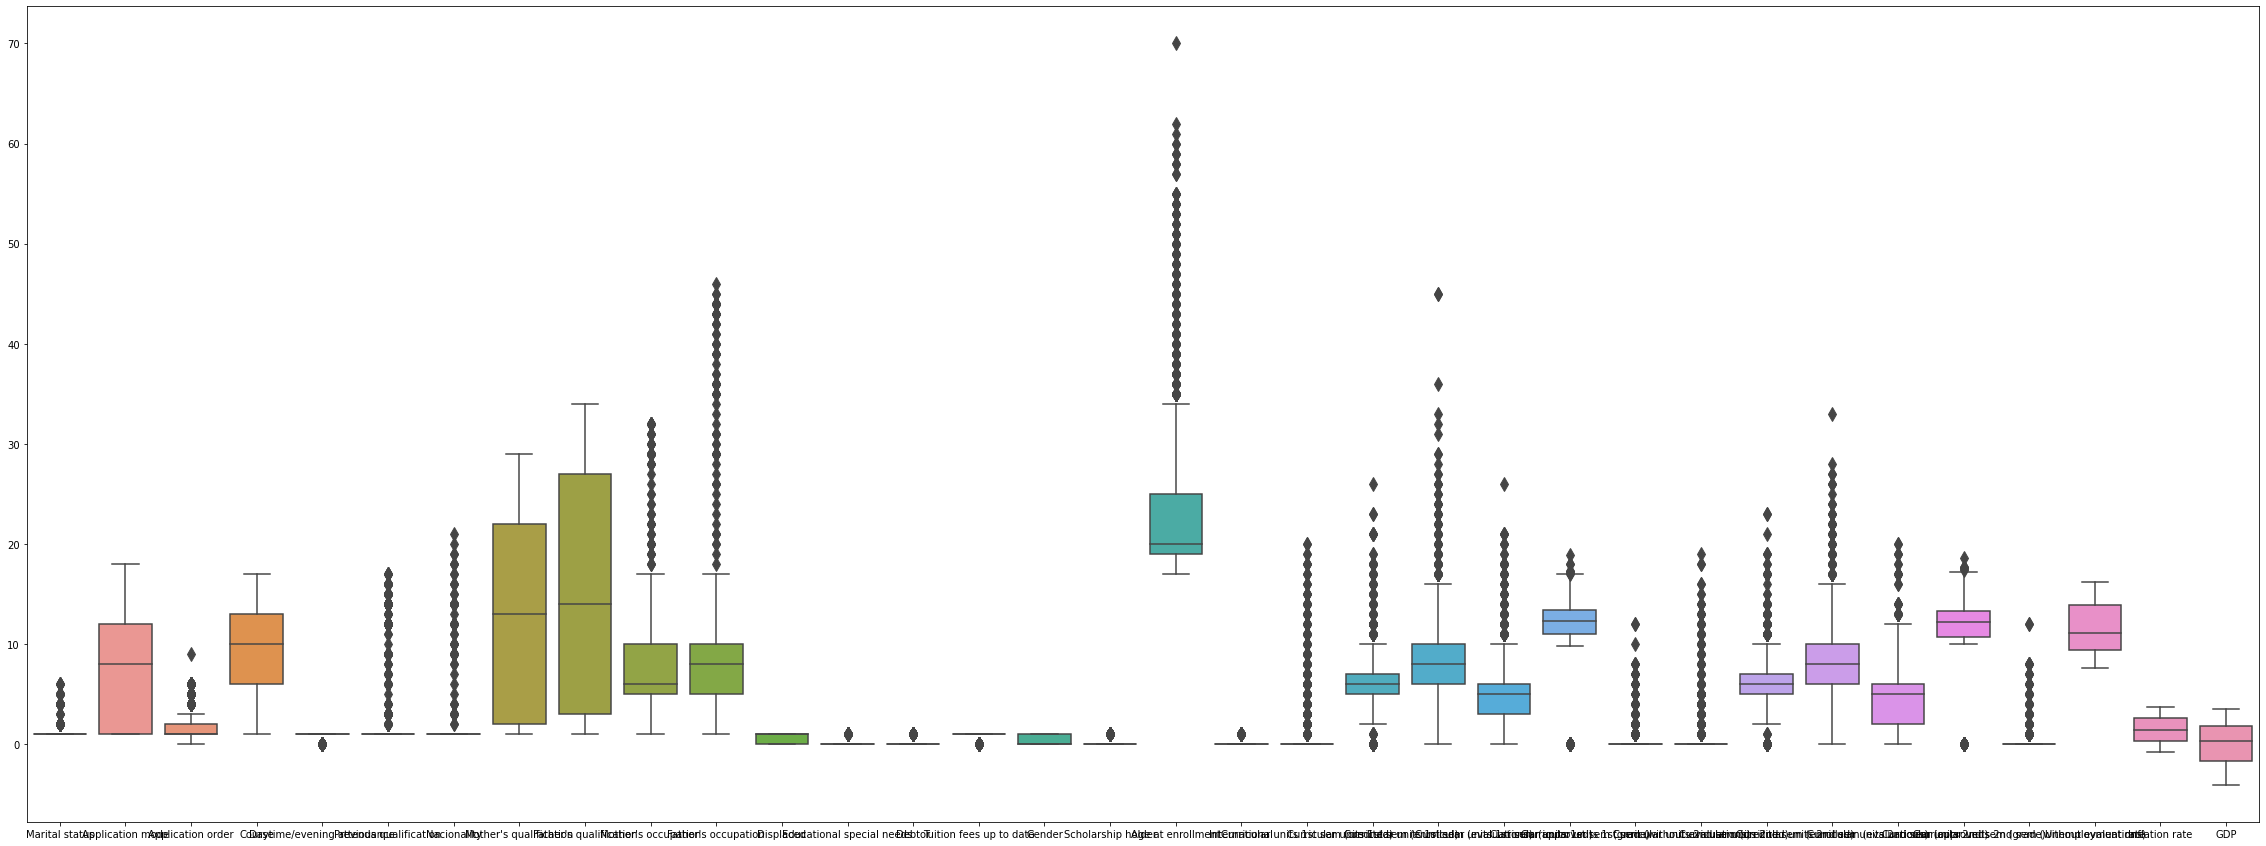

In [ ]:
plt.figure(figsize=(40,15))
sns.boxplot(data=df,fliersize=10)

<AxesSubplot:ylabel='Count'>

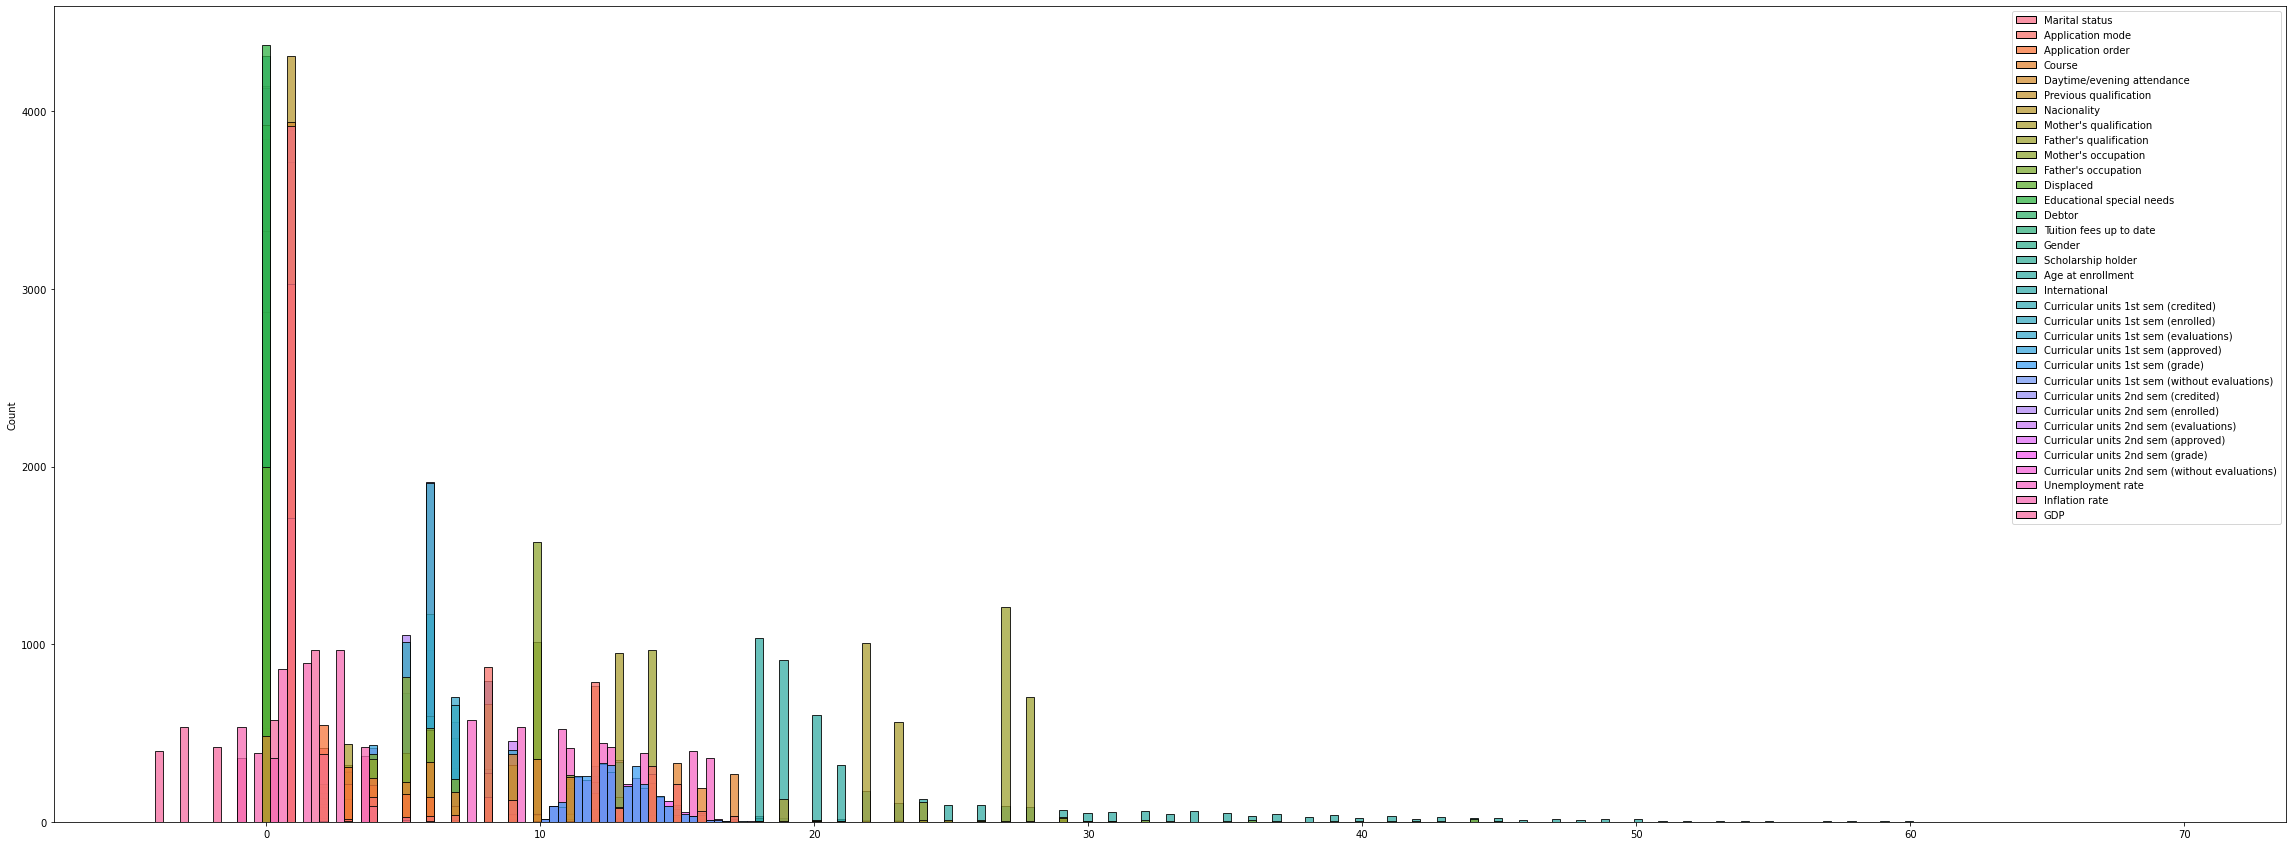

In [ ]:
plt.figure(figsize=(40,15))
sns.histplot(data=df)

In [ ]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [ ]:
df3=df.copy()
for var in df:
    if var =='Target':
        break
    lower=df[var].mean()- 3*df[var].std()
    upper=df[var].mean()+ 3*df[var].std()
    print(lower,upper)
    new_df= df.loc[(df[var] < upper) & (df[var] > lower)]
    print('befour remove outlier',len(df))
    print('after remove outlier',len(new_df))
    print('number of outlier',len(df)-len(new_df))


    df3.loc[df3[var]>upper,var]=upper
    df3.loc[df3[var]<lower,var]=lower



-0.6386694098206371 2.9958122669634943
befour remove outlier 4424
after remove outlier 4298
number of outlier 126
-9.009911054621334 22.783871271619525
befour remove outlier 4424
after remove outlier 4424
number of outlier 0
-2.2135311338206796 5.669227336352325
befour remove outlier 4424
after remove outlier 4286
number of outlier 138
-3.0961896546370564 22.894562168199442
befour remove outlier 4424
after remove outlier 4424
number of outlier 0
-0.04486725963525828 1.8265128292555115
befour remove outlier 4424
after remove outlier 4424
number of outlier 0
-9.359701324884647 14.422540384559149
befour remove outlier 4424
after remove outlier 4342
number of outlier 82
-3.990820715078434 6.499862306398506
befour remove outlier 4424
after remove outlier 4334
number of outlier 90
-14.756646418031657 39.40085979958681
befour remove outlier 4424
after remove outlier 4424
number of outlier 0
-16.67915441540347 49.58964266133475
befour remove outlier 4424
after remove outlier 4424
number of out

In [ ]:
df3

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1.0,8.0,5.000000,2.0,1.0,1.0,1.000000,13.0,10.0,6.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,10.8,1.4,1.74,Dropout
1,1.0,6.0,1.000000,11.0,1.0,1.0,1.000000,1.0,3.0,4.0,...,0.0,6.0,6.0,6.0,13.666667,0.0,13.9,-0.3,0.79,Graduate
2,1.0,1.0,5.000000,5.0,1.0,1.0,1.000000,22.0,27.0,10.0,...,0.0,6.0,0.0,0.0,0.000000,0.0,10.8,1.4,1.74,Dropout
3,1.0,8.0,2.000000,15.0,1.0,1.0,1.000000,23.0,27.0,6.0,...,0.0,6.0,10.0,5.0,12.400000,0.0,9.4,-0.8,-3.12,Graduate
4,2.0,12.0,1.000000,3.0,0.0,1.0,1.000000,22.0,28.0,10.0,...,0.0,6.0,6.0,6.0,13.000000,0.0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1.0,1.0,5.669227,15.0,1.0,1.0,1.000000,1.0,1.0,6.0,...,0.0,6.0,8.0,5.0,12.666667,0.0,15.5,2.8,-4.06,Graduate
4420,1.0,1.0,2.000000,15.0,1.0,1.0,6.499862,1.0,1.0,10.0,...,0.0,6.0,6.0,2.0,11.000000,0.0,11.1,0.6,2.02,Dropout
4421,1.0,1.0,1.000000,12.0,1.0,1.0,1.000000,22.0,27.0,10.0,...,0.0,8.0,9.0,1.0,13.500000,0.0,13.9,-0.3,0.79,Dropout
4422,1.0,1.0,1.000000,9.0,1.0,1.0,1.000000,22.0,27.0,8.0,...,0.0,5.0,6.0,5.0,12.000000,0.0,9.4,-0.8,-3.12,Graduate


In [ ]:
for var in df3:

    print(df3[var].value_counts())

1.000000    3919
2.000000     379
2.995812     126
Name: Marital status, dtype: int64
1.0     1708
8.0      872
12.0     785
14.0     312
15.0     213
4.0      139
9.0      124
13.0      77
16.0      59
7.0       38
17.0      35
6.0       30
3.0       16
5.0       10
2.0        3
11.0       1
10.0       1
18.0       1
Name: Application mode, dtype: int64
1.000000    3026
2.000000     547
3.000000     309
4.000000     249
5.000000     154
5.669227     138
0.000000       1
Name: Application order, dtype: int64
12.0    766
9.0     380
10.0    355
6.0     337
15.0    331
14.0    268
17.0    268
11.0    252
5.0     226
2.0     215
3.0     215
4.0     210
16.0    192
7.0     170
8.0     141
13.0     86
1.0      12
Name: Course, dtype: int64
1.0    3941
0.0     483
Name: Daytime/evening attendance, dtype: int64
1.00000     3717
14.00000     219
12.00000     162
3.00000      126
14.42254      82
9.00000       45
2.00000       23
6.00000       16
7.00000       11
4.00000        8
13.00000      

<AxesSubplot:>

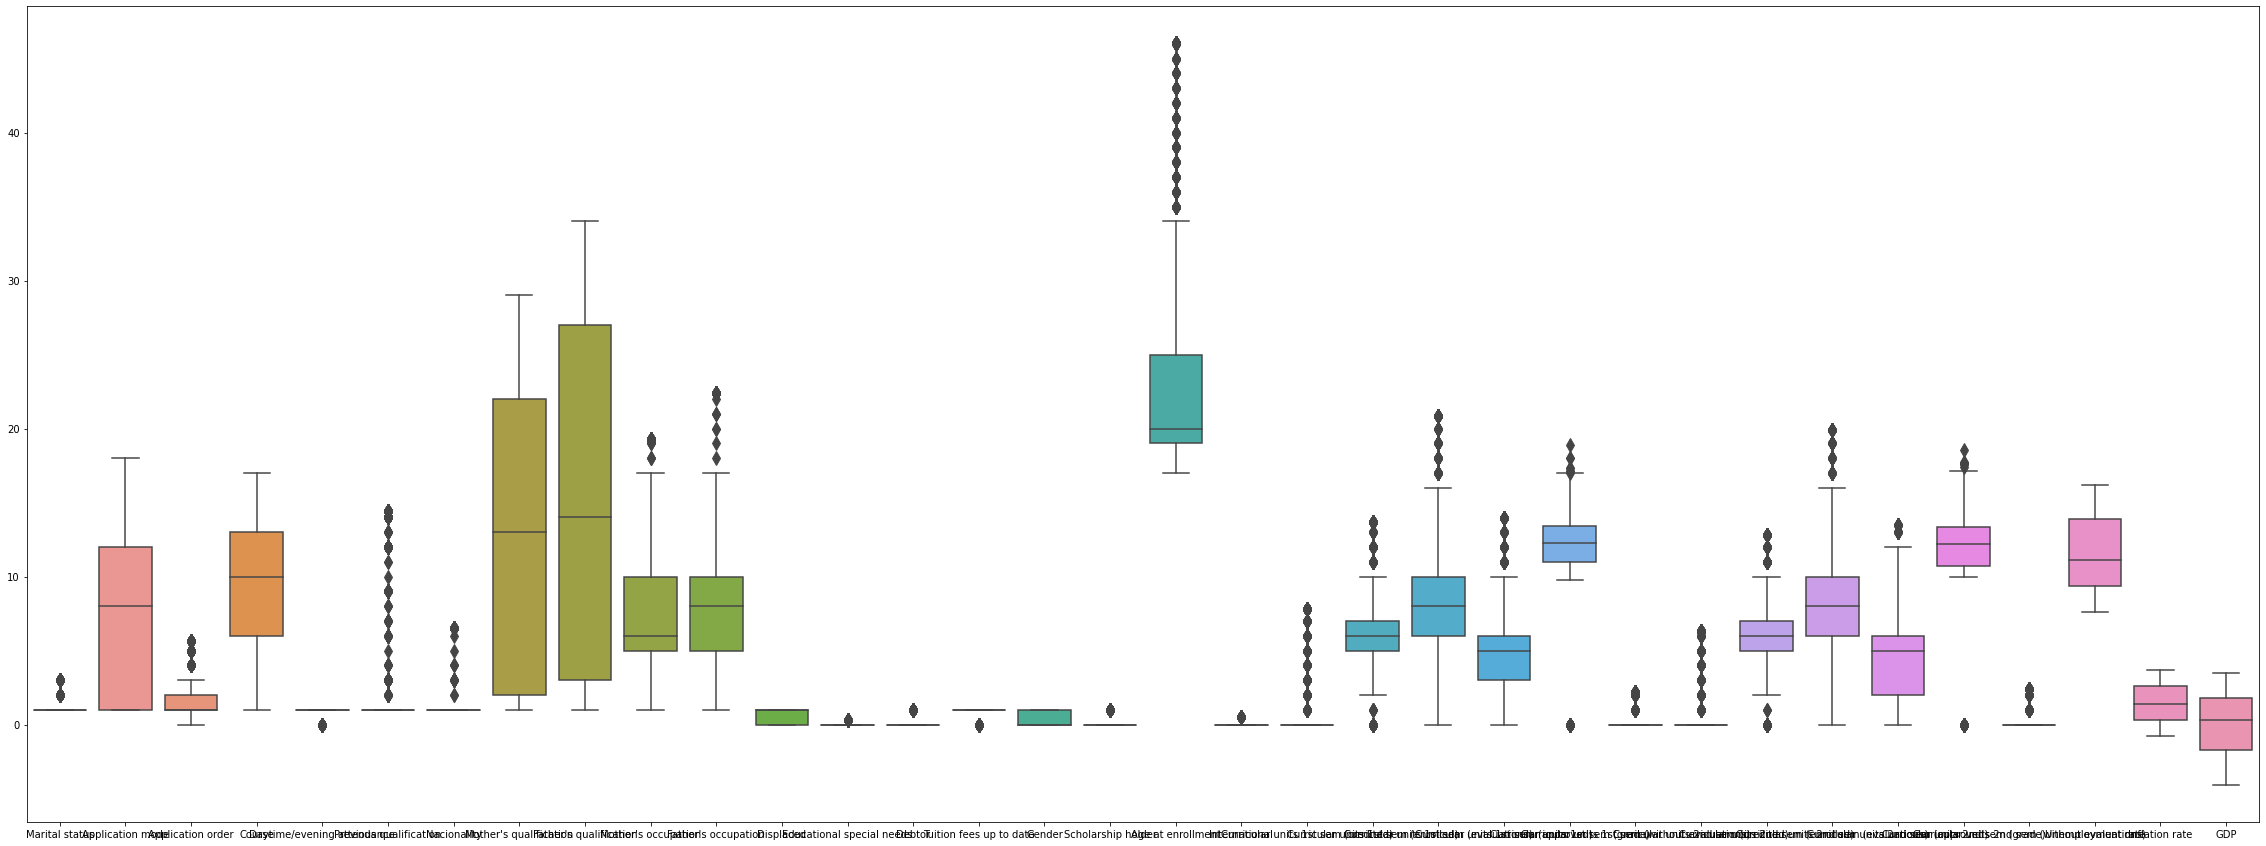

In [ ]:
plt.figure(figsize=(40,15))
sns.boxplot(data=df3,fliersize=10)

<AxesSubplot:ylabel='Count'>

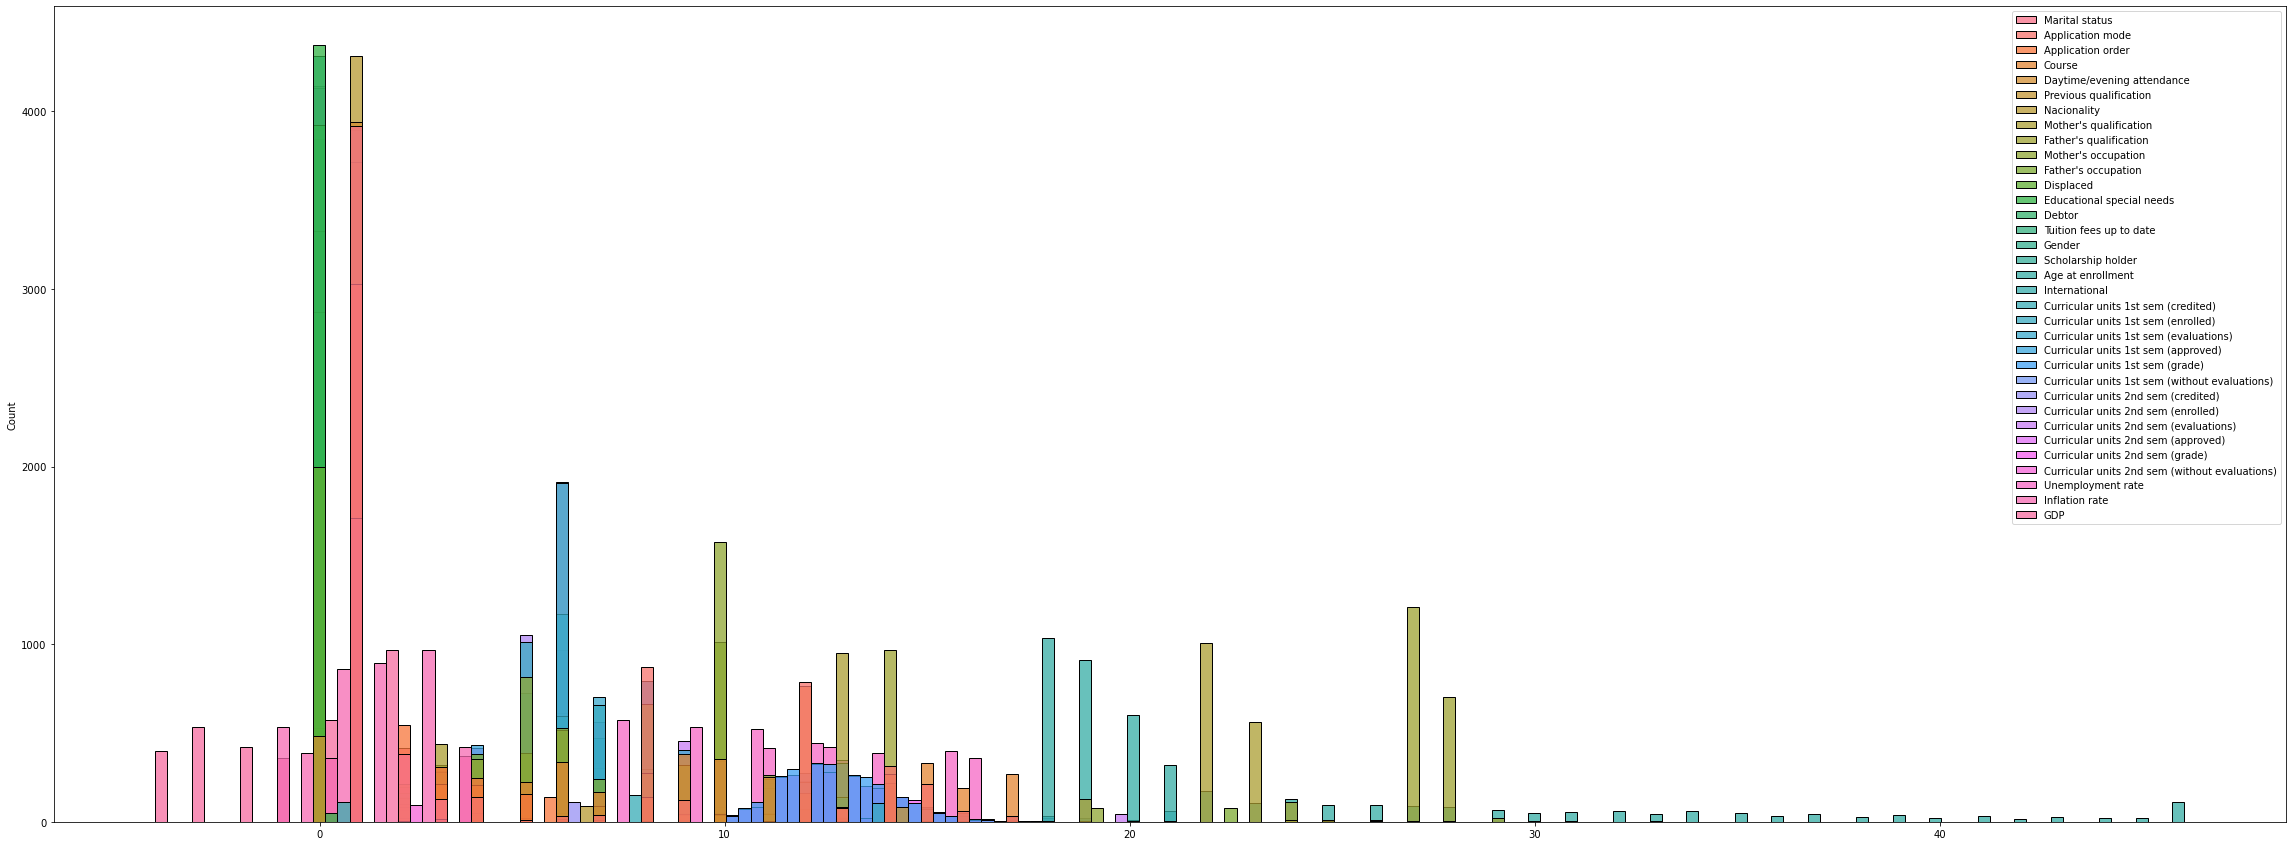

In [ ]:
plt.figure(figsize=(40,15))
sns.histplot(data=df3)

In [ ]:
df2=df.copy()
for var in df:
    if var =='Target':
        break
    seventy_fifth=df[var].quantile(0.75)
    twenty_fifth=df[var].quantile(0.25)
    IQR=seventy_fifth-twenty_fifth
    lower=twenty_fifth-(IQR*1.5)
    upper=seventy_fifth+(IQR*1.5)
    print(lower,upper)
    new_df= df.loc[(df[var] < upper) & (df[var] > lower)]
    print('befour remove outlier',len(df))
    print('after remove outlier',len(new_df))
    print('number of outlier',len(df)-len(new_df))


    df2.loc[df2[var]>upper,var]=upper
    df2.loc[df2[var]<lower,var]=lower



1.0 1.0
befour remove outlier 4424
after remove outlier 0
number of outlier 4424
-15.5 28.5
befour remove outlier 4424
after remove outlier 4424
number of outlier 0
-0.5 3.5
befour remove outlier 4424
after remove outlier 3883
number of outlier 541
-4.5 23.5
befour remove outlier 4424
after remove outlier 4424
number of outlier 0
1.0 1.0
befour remove outlier 4424
after remove outlier 0
number of outlier 4424
1.0 1.0
befour remove outlier 4424
after remove outlier 0
number of outlier 4424
1.0 1.0
befour remove outlier 4424
after remove outlier 0
number of outlier 4424
-28.0 52.0
befour remove outlier 4424
after remove outlier 4424
number of outlier 0
-33.0 63.0
befour remove outlier 4424
after remove outlier 4424
number of outlier 0
-2.5 17.5
befour remove outlier 4424
after remove outlier 4340
number of outlier 84
-2.5 17.5
befour remove outlier 4424
after remove outlier 4340
number of outlier 84
-1.5 2.5
befour remove outlier 4424
after remove outlier 4424
number of outlier 0
0.0 0.0

In [ ]:
df2

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1.0,8.0,3.5,2.0,1.0,1.0,1.0,13.0,10.0,6.0,...,0.0,2.0,0.0,0.0,6.875000,0.0,10.8,1.4,1.74,Dropout
1,1.0,6.0,1.0,11.0,1.0,1.0,1.0,1.0,3.0,4.0,...,0.0,6.0,6.0,6.0,13.666667,0.0,13.9,-0.3,0.79,Graduate
2,1.0,1.0,3.5,5.0,1.0,1.0,1.0,22.0,27.0,10.0,...,0.0,6.0,0.0,0.0,6.875000,0.0,10.8,1.4,1.74,Dropout
3,1.0,8.0,2.0,15.0,1.0,1.0,1.0,23.0,27.0,6.0,...,0.0,6.0,10.0,5.0,12.400000,0.0,9.4,-0.8,-3.12,Graduate
4,1.0,12.0,1.0,3.0,1.0,1.0,1.0,22.0,28.0,10.0,...,0.0,6.0,6.0,6.0,13.000000,0.0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1.0,1.0,3.5,15.0,1.0,1.0,1.0,1.0,1.0,6.0,...,0.0,6.0,8.0,5.0,12.666667,0.0,15.5,2.8,-4.06,Graduate
4420,1.0,1.0,2.0,15.0,1.0,1.0,1.0,1.0,1.0,10.0,...,0.0,6.0,6.0,2.0,11.000000,0.0,11.1,0.6,2.02,Dropout
4421,1.0,1.0,1.0,12.0,1.0,1.0,1.0,22.0,27.0,10.0,...,0.0,8.0,9.0,1.0,13.500000,0.0,13.9,-0.3,0.79,Dropout
4422,1.0,1.0,1.0,9.0,1.0,1.0,1.0,22.0,27.0,8.0,...,0.0,5.0,6.0,5.0,12.000000,0.0,9.4,-0.8,-3.12,Graduate


<AxesSubplot:>

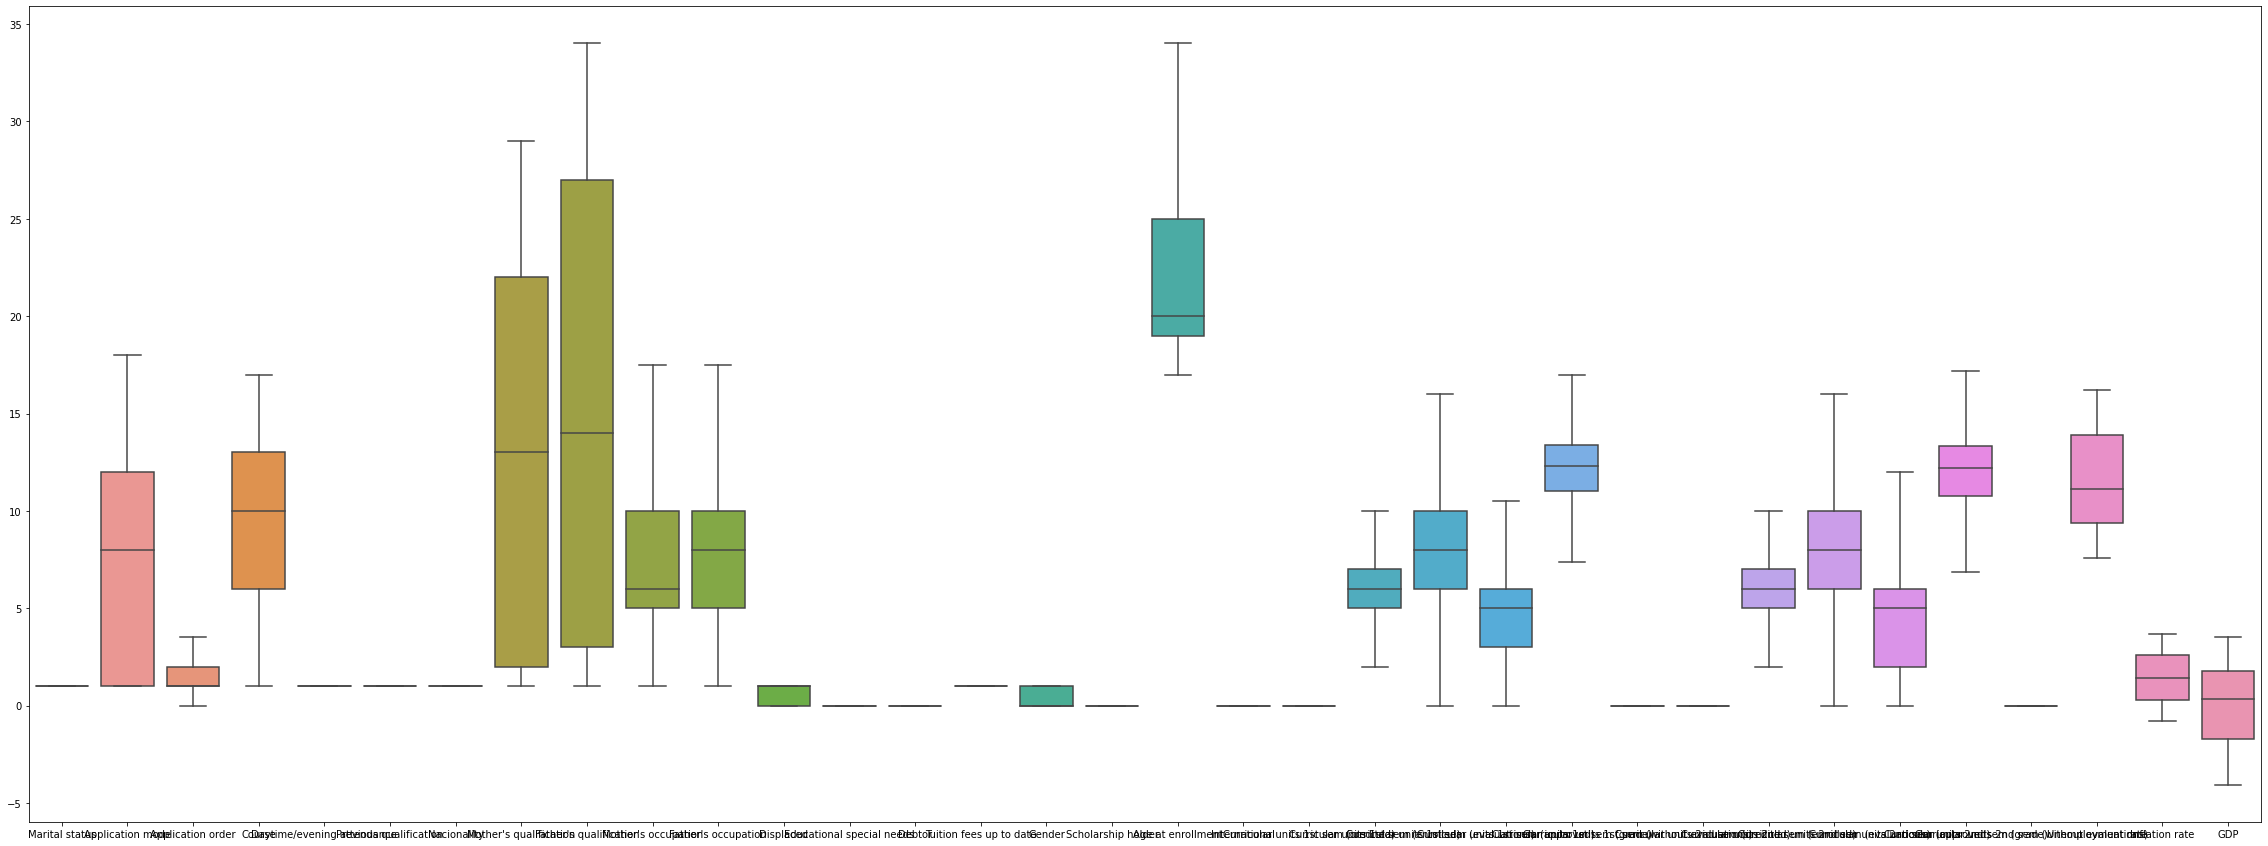

In [ ]:
plt.figure(figsize=(40,15))
sns.boxplot(data=df2,fliersize=10)

In [ ]:
for var in df2:

    print(df2[var].value_counts())

1.0    4424
Name: Marital status, dtype: int64
1.0     1708
8.0      872
12.0     785
14.0     312
15.0     213
4.0      139
9.0      124
13.0      77
16.0      59
7.0       38
17.0      35
6.0       30
3.0       16
5.0       10
2.0        3
11.0       1
10.0       1
18.0       1
Name: Application mode, dtype: int64
1.0    3026
2.0     547
3.5     541
3.0     309
0.0       1
Name: Application order, dtype: int64
12.0    766
9.0     380
10.0    355
6.0     337
15.0    331
14.0    268
17.0    268
11.0    252
5.0     226
2.0     215
3.0     215
4.0     210
16.0    192
7.0     170
8.0     141
13.0     86
1.0      12
Name: Course, dtype: int64
1.0    4424
Name: Daytime/evening attendance, dtype: int64
1.0    4424
Name: Previous qualification, dtype: int64
1.0    4424
Name: Nacionality, dtype: int64
1.0     1069
22.0    1009
13.0     953
23.0     562
3.0      438
19.0     130
2.0       83
4.0       49
10.0      42
5.0       21
25.0       9
7.0        8
24.0       8
26.0       6
28.0       4


<AxesSubplot:ylabel='Count'>

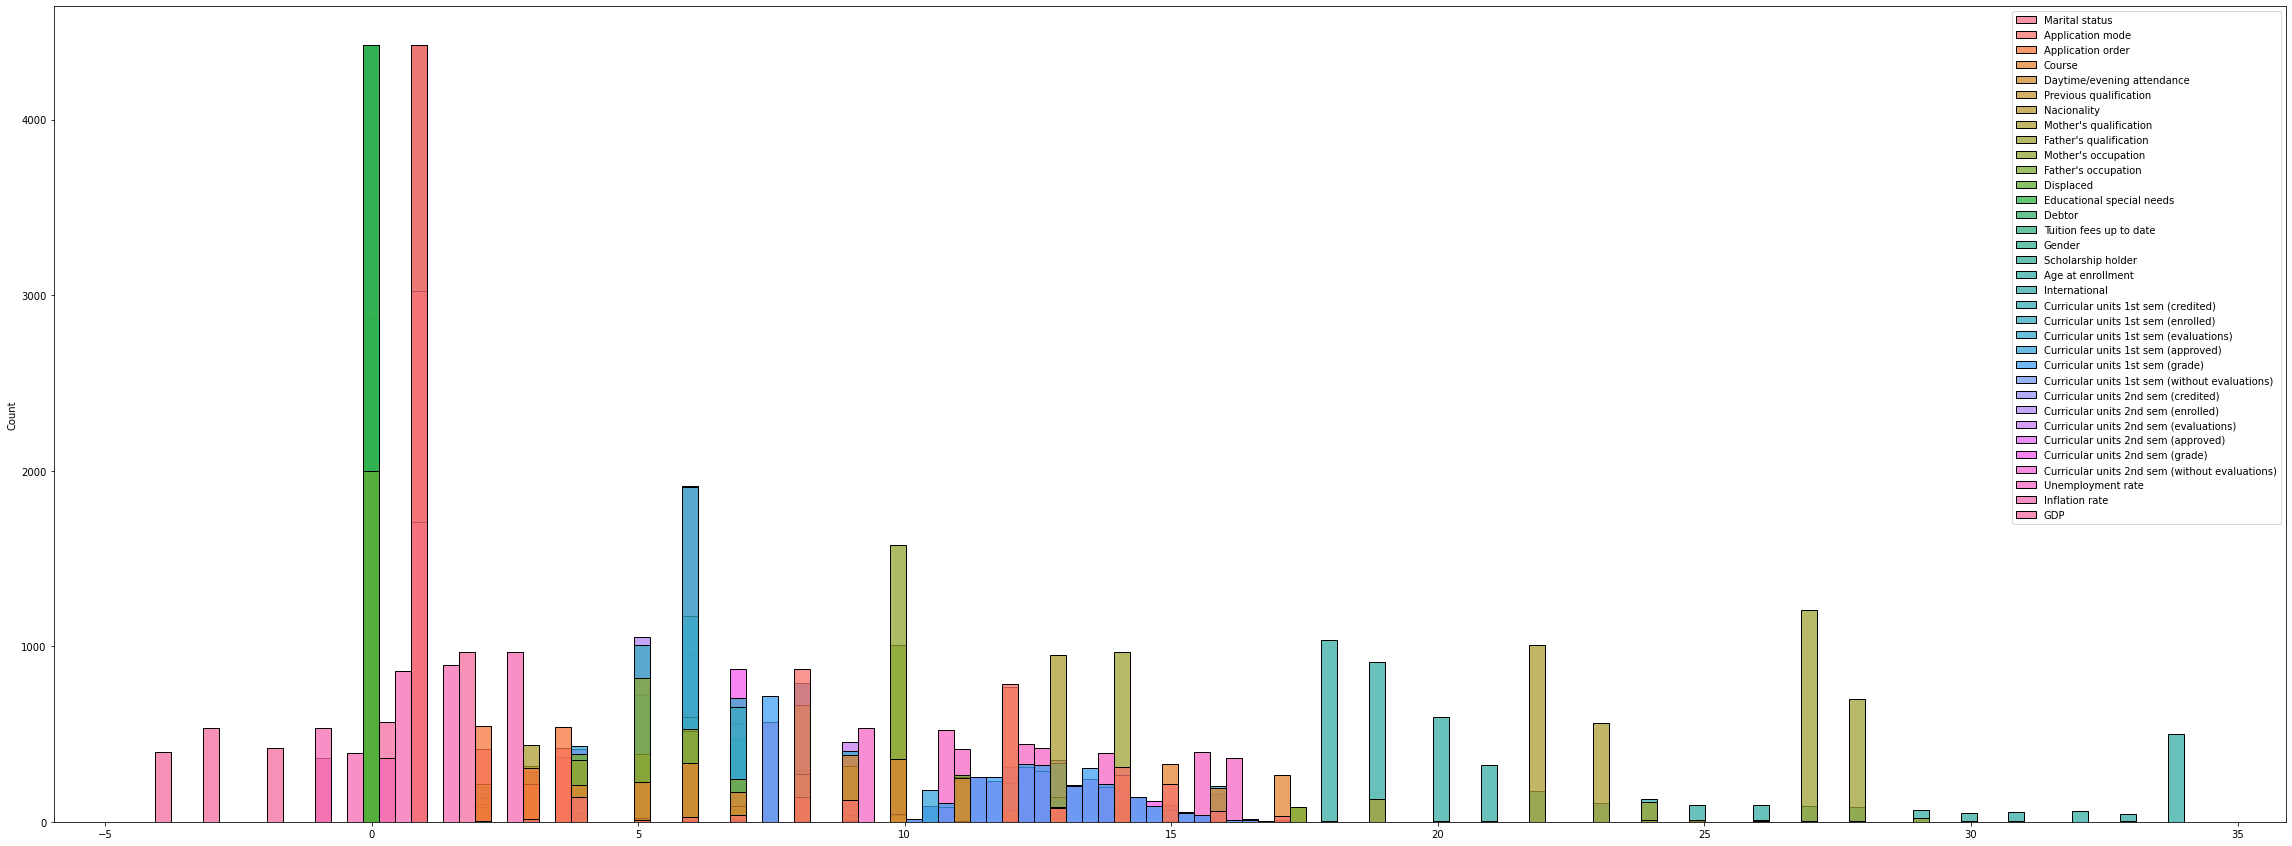

In [ ]:
plt.figure(figsize=(40,15))
sns.histplot(data=df2)

# split the data set into feature and target

In [ ]:
x=df3.drop('Target',axis=1)
y=df3['Target']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split( x , y , test_size=0.2 , random_state=0)

In [ ]:
x_train.shape, x_test.shape

((3539, 34), (885, 34))

In [ ]:
cols=x.columns
cols

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

In [ ]:
df2.var()

Marital status                                      0.000000
Application mode                                   28.079017
Application order                                   0.844176
Course                                             18.764422
Daytime/evening attendance                          0.000000
Previous qualification                              0.000000
Nacionality                                         0.000000
Mother's qualification                             81.473208
Father's qualification                            121.987596
Mother's occupation                                10.559847
Father's occupation                                 9.757061
Displaced                                           0.247716
Educational special needs                           0.000000
Debtor                                              0.000000
Tuition fees up to date                             0.000000
Gender                                              0.228064
Scholarship holder      

# Feature Engineering and scalling the data

In [ ]:
mms=MinMaxScaler()
x_train=mms.fit_transform(x_train)
x_test=mms.transform(x_test)
x_train = pd.DataFrame(x_train, columns=cols)
x_test = pd.DataFrame(x_test, columns=cols)
x_train.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,0.000000,0.647059,0.176391,0.1875,1.0,0.0,0.0,0.750000,0.81250,0.273056,...,0.000000,0.0,0.468019,0.653032,0.370917,0.673077,0.000000,1.000000,0.244444,0.414795
1,0.000000,0.823529,0.176391,0.1875,1.0,0.0,0.0,0.000000,0.00000,0.218444,...,0.000000,0.0,0.468019,0.602799,0.370917,0.634188,0.000000,1.000000,0.244444,0.414795
2,0.501049,0.647059,0.176391,0.1875,1.0,0.0,0.0,0.000000,0.40625,0.218444,...,0.904855,0.0,0.468019,0.653032,0.000000,0.000000,0.414656,0.918605,0.800000,0.000000
3,0.000000,0.000000,0.176391,0.7500,1.0,0.0,0.0,0.750000,0.84375,0.382278,...,0.000000,0.0,0.624025,0.401866,0.593468,0.621923,0.000000,0.593023,1.000000,0.311757
4,0.000000,0.000000,0.352782,0.2500,1.0,0.0,0.0,0.428571,0.84375,0.491500,...,0.000000,0.0,0.468019,0.401866,0.445101,0.666346,0.000000,0.372093,0.488889,0.766182


In [ ]:
x_train.var()

Marital status                                    0.044340
Application mode                                  0.097537
Application order                                 0.051265
Course                                            0.073681
Daytime/evening attendance                        0.100935
Previous qualification                            0.082376
Nacionality                                       0.022558
Mother's qualification                            0.104140
Father's qualification                            0.118504
Mother's occupation                               0.034158
Father's occupation                               0.026625
Displaced                                         0.247142
Educational special needs                         0.012006
Debtor                                            0.100935
Tuition fees up to date                           0.105913
Gender                                            0.226825
Scholarship holder                                0.1898

# logistic model

In [ ]:
lg=LogisticRegression(solver='lbfgs',max_iter=150)

In [ ]:
lg.fit(x_train,y_train)

LogisticRegression(max_iter=150)

In [ ]:
y_pred=lg.predict(x_test)

In [ ]:
lg.classes_

array(['Dropout', 'Enrolled', 'Graduate'], dtype=object)

In [ ]:
lg.coef_

array([[-2.75949547e-01,  4.79235429e-04,  4.39423931e-01,
         9.85636127e-01,  6.06082873e-02,  6.53760701e-02,
        -3.80543848e-03,  2.72323227e-01,  1.46671600e-02,
        -6.59244148e-01, -2.29268353e-01,  1.40441711e-01,
         7.84902217e-02,  3.15124785e-01, -1.67840742e+00,
         2.60473019e-01, -3.15235923e-01,  9.81608402e-01,
        -5.07220949e-01,  1.87720645e-01,  1.72079102e+00,
         1.32772013e-01, -2.48428794e+00,  9.34927702e-02,
         3.18271810e-01,  9.38176482e-01,  2.47720623e+00,
         1.53425564e-01, -4.43811922e+00, -1.48355520e+00,
        -6.86647801e-02,  4.53818887e-01,  6.21901559e-02,
         1.70598833e-01],
       [ 5.29886786e-03,  2.16130548e-01, -3.53217574e-01,
        -1.05924229e-01, -7.66410799e-04, -3.31540843e-01,
        -1.85913447e-01, -3.04580478e-01, -1.34981121e-01,
         3.32994189e-01,  5.31409320e-01, -7.68755384e-02,
        -3.51865975e-02,  2.36888189e-01,  4.95514930e-01,
        -1.60130046e-02, -1.83

In [ ]:
print('Accuracy:',metrics.accuracy_score(y_test,y_pred))


Accuracy: 0.784180790960452


In [ ]:
print('precision:',metrics.precision_score(y_test,y_pred,average='micro'))

precision: 0.784180790960452


In [ ]:
print('Recall:',metrics.recall_score(y_test,y_pred,average='micro'))

Recall: 0.784180790960452


In [ ]:
confusion_matrics=metrics.confusion_matrix(y_test,y_pred )
confusion_matrics

array([[219,  26,  39],
       [ 37,  55,  59],
       [ 13,  17, 420]], dtype=int64)

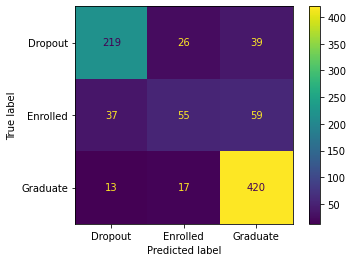

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrics, display_labels=['Dropout', 'Enrolled','Graduate'])
disp.plot()
plt.show()

# knn classifier model

In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
knn.score(x_test,y_test)

0.6790960451977401

In [ ]:
knn.score(x_train,y_train)

0.7824244136761798

# svm model

In [ ]:
svm=SVC(kernel='linear')

In [ ]:
#SVC.fit(x_train,y_train)

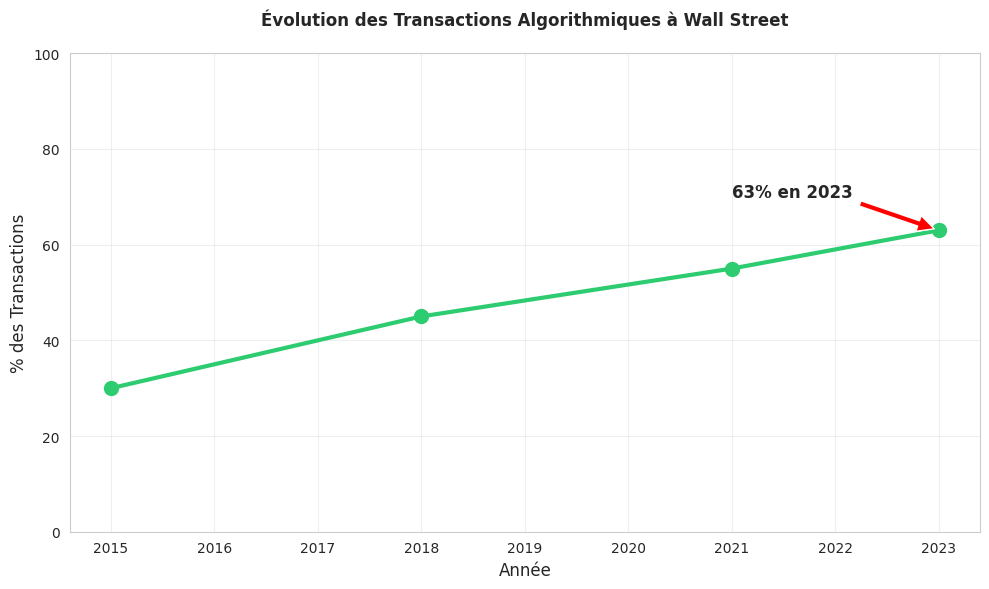

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Données (exemple)
années = [2015, 2018, 2021, 2023]
transactions_algo = [30, 45, 55, 63]  # en %

# Style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Graphique
plt.plot(années, transactions_algo, marker='o', linestyle='-', color='#2ecc71', linewidth=3, markersize=10)

# Personnalisation
plt.title("Évolution des Transactions Algorithmiques à Wall Street", fontweight='bold', pad=20)
plt.xlabel("Année", fontsize=12)
plt.ylabel("% des Transactions", fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

# Ajout du point clé 2023
plt.annotate('63% en 2023', xy=(2023, 63), xytext=(2021, 70),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig('transactions_algo.png', dpi=300)  # Sauvegarde pour ton slide
plt.show()